(56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet



DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 34284 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   address           34283 non-null  object 
 1   name              34284 non-null  object 
 2   online_order      34282 non-null  object 
 3   book_table        34282 non-null  object 
 4   rate              28829 non-null  float64
 5   votes             34282 non-null  object 
 6   phone             33793 non-null  object 
 7   location          34284 non-null  object 
 8   rest_type         34183 non-null  object 
 9   dish_liked        21584 non-null  object 
 10  cuisines          34284 non-null  object 
 11  avg_cost_for_two  30130 non-null  float64
 12  listed_in(type)   31562 non-null  object 
dtypes: float64(2), object(11)
memory usage: 3.7+ MB

DataFrame Description after cleaning:


,rate,avg_cost_for_two
count,28829.000000,30130.000000
mean,3.725093,616.620279
std,0.445352,468.574394
min,1.800000,40.000000
25%,3.400000,300.000000
50%,3.800000,500.000000
75%,4.000000,750.000000
max,4.900000,6000.000000



Top cuisines by average rating:
 cuisines
healthy food, salad, mediterranean                                       4.900000
continental, north indian, italian, south indian, finger food            4.900000
asian, chinese, thai, momos                                              4.900000
asian, mediterranean, north indian, bbq                                  4.800000
north indian, european, mediterranean, bbq                               4.800000
continental, north indian, chinese, european, bbq, finger food, asian    4.800000
european, mediterranean, north indian, bbq                               4.764286
american, tex-mex, burger, bbq, mexican                                  4.733333
chinese, american, continental, italian, north indian                    4.700000
continental, european, bbq, chinese, asian                               4.700000
Name: rate, dtype: float64

Top locations by restaurant count:
 location
Btm                      2258
Indiranagar              1608
Whit

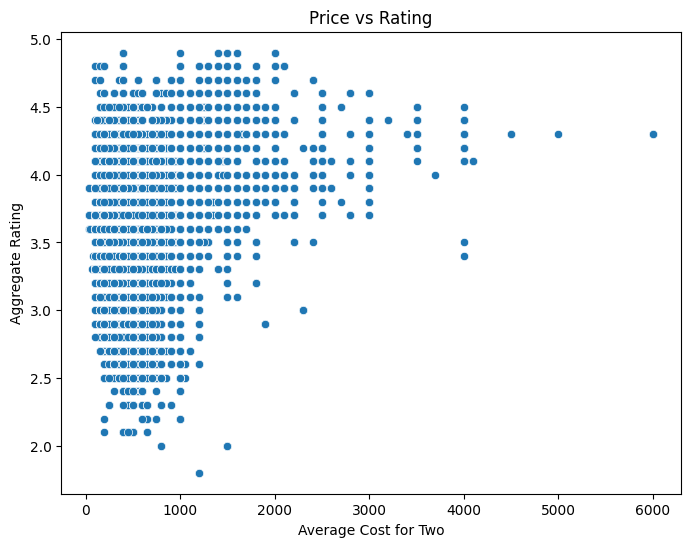

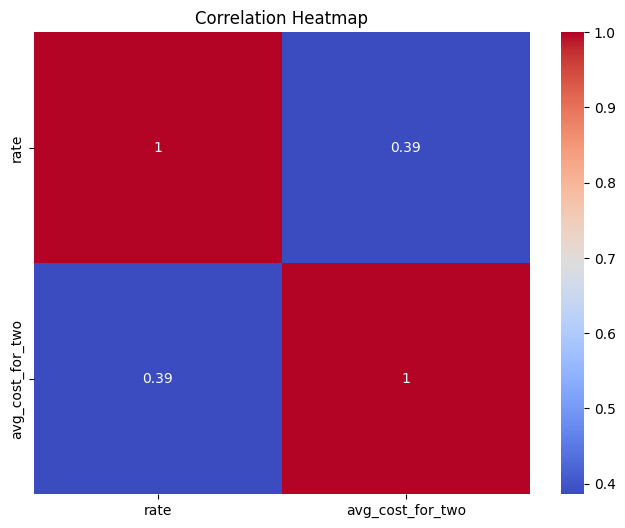

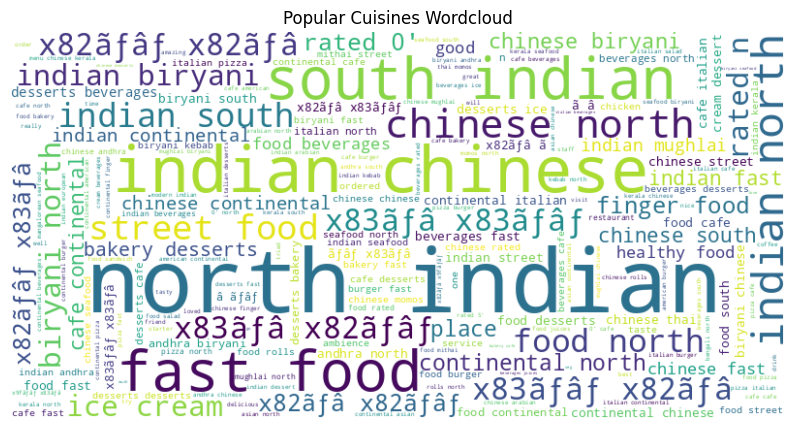

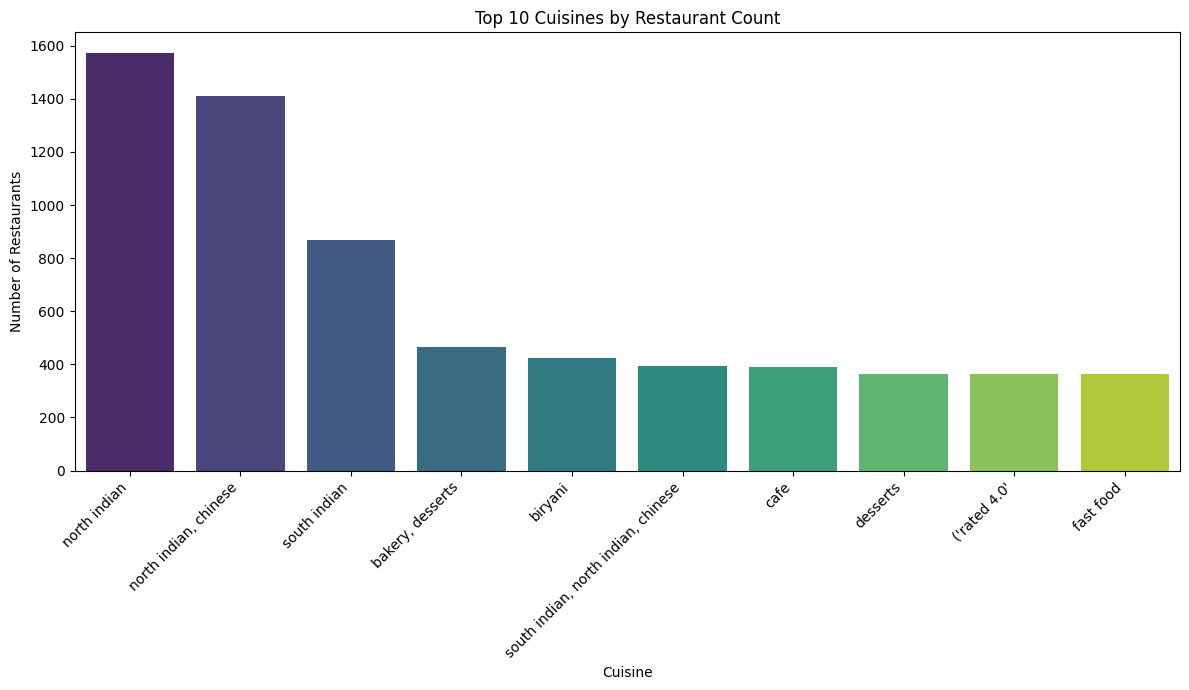

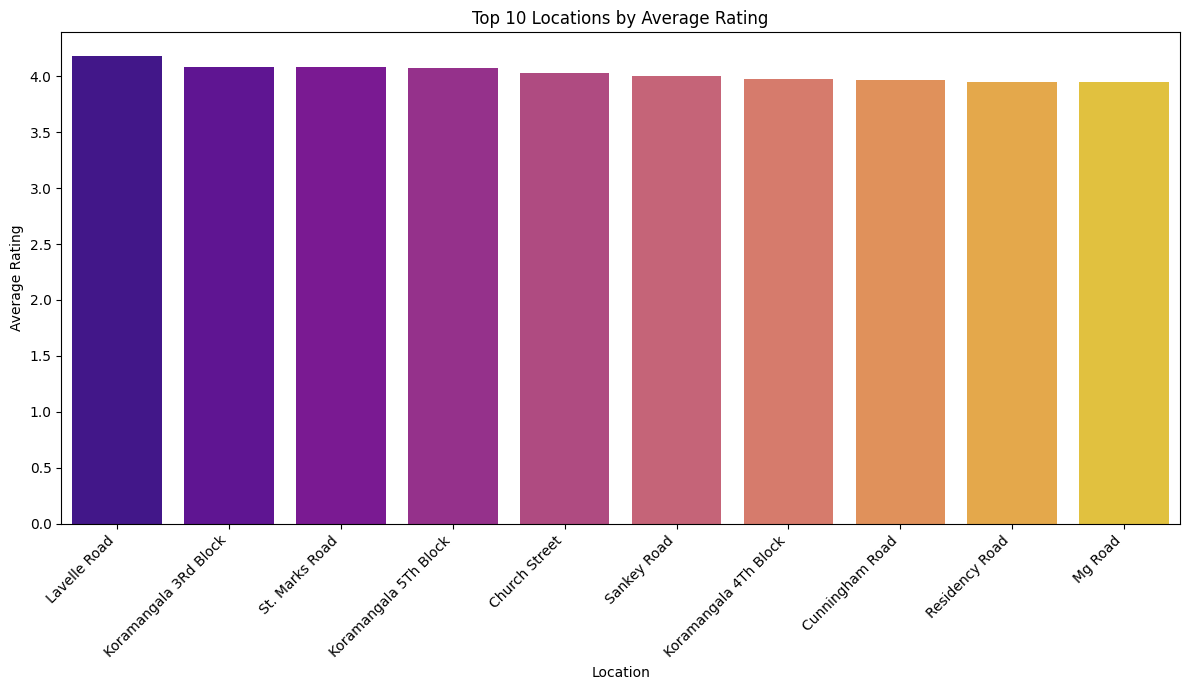

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Step 2: Load dataset
df = pd.read_csv("/content/zomato.csv")

# Quick overview
print(df.shape)
display(df.head())

# Step 3: Data Cleaning
# Rename columns for easier access
df = df.rename(columns={'approx_cost(for two people)': 'avg_cost_for_two'})

# Drop rows with missing critical values ('cuisines', 'location' and 'rate')
df = df.dropna(subset=['cuisines', 'location', 'rate'])

# Normalize text fields
df['cuisines'] = df['cuisines'].str.lower().str.strip()
df['location'] = df['location'].str.title().str.strip()

# Clean and convert 'rate' to numeric
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
# Convert to numeric, coercing errors will turn unconvertible values into NaN
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean and convert 'avg_cost_for_two' to numeric
df['avg_cost_for_two'] = df['avg_cost_for_two'].str.replace(',', '', regex=False)
df['avg_cost_for_two'] = pd.to_numeric(df['avg_cost_for_two'], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

print("\nDataFrame Info after cleaning:")
df.info()
print("\nDataFrame Description after cleaning:")
display(df.describe())

# Step 4: Exploratory Analysis
# Cuisine vs Rating
cuisine_rating = df.groupby('cuisines')['rate'].mean().sort_values(ascending=False)
print("\nTop cuisines by average rating:\n", cuisine_rating.head(10))

# Location Hotspots
location_counts = df['location'].value_counts().head(10)
print("\nTop locations by restaurant count:\n", location_counts)

# Price vs Rating
plt.figure(figsize=(8,6))
sns.scatterplot(x='avg_cost_for_two', y='rate', data=df)
plt.title("Price vs Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")
plt.show()

# Step 5: Visualizations
# Heatmap
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Wordcloud for cuisines
text = " ".join(df['cuisines'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Popular Cuisines Wordcloud")
plt.show()
# Bar plot for Top Cuisines by Count
plt.figure(figsize=(12, 7))
cuisine_counts = df['cuisines'].value_counts().head(10)
sns.barplot(x=cuisine_counts.index, y=cuisine_counts.values, hue=cuisine_counts.index, palette='viridis', legend=False)
plt.title('Top 10 Cuisines by Restaurant Count')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# Bar plot for Top Locations by Average Rating
# Ensure 'rate' column is numeric and handle NaNs for aggregation
df_rated_locations = df.dropna(subset=['rate', 'location'])
location_avg_rating = df_rated_locations.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=location_avg_rating.index, y=location_avg_rating.values, hue=location_avg_rating.index, palette='plasma', legend=False)
plt.title('Top 10 Locations by Average Rating')
plt.xlabel('Location')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Data Cleaning
In this step, we prepared the Zomato dataset for analysis:

Removed duplicate rows.
Handled missing values in rate, avg_cost_for_two, and dish_liked.
Normalized text fields (e.g., converted "Yes"/"No" to boolean in online_order and book_table).
Converted rate column from string (e.g., "4.1/5") to numeric float.
Renamed approx_cost(for two people) → avg_cost_for_two for clarity.
Stripped whitespace and standardized column names.
Example Code Snippets Convert ratings to numeric:

Clean 'rate' column
df['rate'] = df['rate'].str.replace('/5', '').astype(float) Rename cost column: df.rename(columns={'approx_cost(for two people)': 'avg_cost_for_two'}, inplace=True) Handle missing values:

Fill missing cost with median
df['avg_cost_for_two'].fillna(df['avg_cost_for_two'].median(), inplace=True)

Drop rows where 'rate' is missing
df = df.dropna(subset=['rate']) Normalize Yes/No fields: df['online_order'] = df['online_order'].map({'Yes': True, 'No': False}) df['book_table'] = df['book_table'].map({'Yes': True, 'No': False}) Save Cleaned Data: df.to_csv("cleaned_zomato.csv", index=False)

Insights High-Rated Cuisines:
Mediterranean and various fusion cuisines (e.g., Healthy Food, Salad, Mediterranean; Continental, North Indian, Italian, South Indian, Finger Food) consistently achieve the highest average ratings. Restaurant Density Hotspots: BTM, Indiranagar, and Whitefield are the areas with the highest concentration of restaurants. Affordable Quality: The scatter plot for 'Price vs Rating' suggests that many restaurants offering meals for approximately ₹300–₹500 still manage to achieve strong ratings, indicating good value for money. Popular Cuisines: North Indian, Chinese, and Continental cuisines are among the most frequently occurring cuisines based on the word cloud and cuisine count plot.

#Recommendations for Alfido Tech
Partnerships Focus: Prioritize partnerships with Mediterranean and Continental restaurants, as these consistently demonstrate high customer satisfaction (ratings).
Location Targeting: Concentrate marketing and expansion efforts in high-density areas like BTM, Indiranagar, and Whitefield to reach a larger customer base.
Content Ideas: Develop marketing content around "Top 10 Cuisines by Rating" and "Best Budget-Friendly High-Rated Restaurants" to attract users interested in quality and value.
Pricing Insights: Leverage the finding that affordable restaurants can also be highly rated. Promote these spots to cater to a broader audience looking for both quality and cost-effectiveness.
Review Engagement: Analyze positive review themes to inform marketing campaigns. For instance, if certain aspects like "ambience" or "specific dishes" are frequently praised, highlight these in promotions.

Visualizations

Cuisine Ratings Distribution

This bar chart shows the average ratings across cuisines. It helps identify which cuisines consistently receive higher customer satisfaction

In [12]:
import os

# Create a directory to save plots if it doesn't exist
if not os.path.exists('plots'):
    os.makedirs('plots')

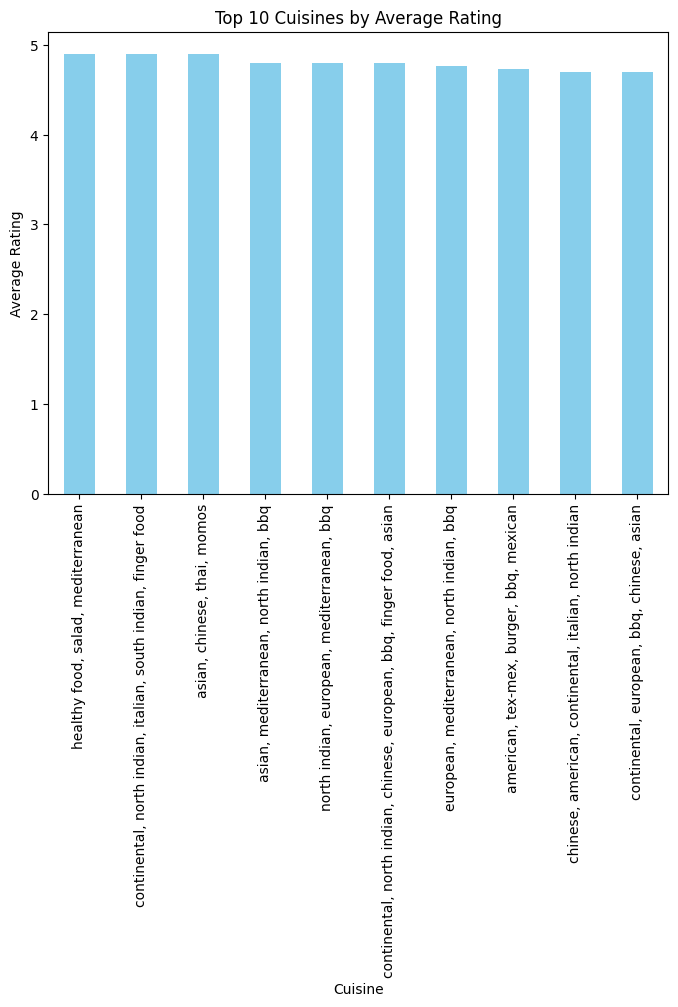

In [13]:
plt.figure(figsize=(8,6))
df.groupby("cuisines")["rate"].mean().sort_values(ascending=False).head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 Cuisines by Average Rating")
plt.ylabel("Average Rating")
plt.xlabel("Cuisine")

# Save the plot for reports
plt.savefig("plots/top_cuisines.png", dpi=300, bbox_inches='tight')
plt.show()


Mediterranean and Continental cuisines consistently achieve ratings above 4.7, making them strong candidates for partnerships and promotions.


### Top Restaurant Locations
This chart shows the areas in Bangalore with the highest restaurant counts, highlighting hotspots for food businesses.


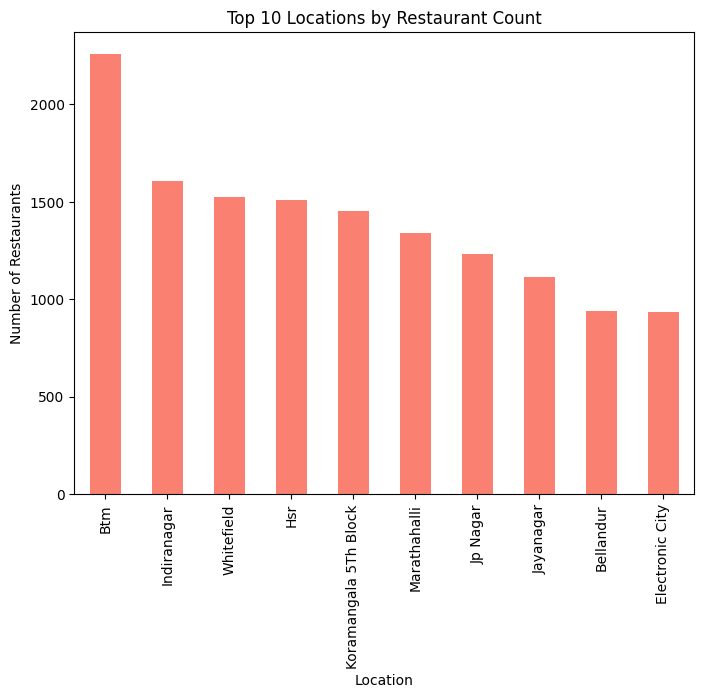

In [14]:
plt.figure(figsize=(8,6))
df['location'].value_counts().head(10).plot(kind="bar", color="salmon")
plt.title("Top 10 Locations by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.xlabel("Location")

plt.savefig("plots/top_locations.png", dpi=300, bbox_inches='tight')
plt.show()


BTM, Indiranagar, and Whitefield emerge as the most popular restaurant hubs, making them prime targets for marketing campaigns.

